# Camera exposure rectification

## Imports

In [1]:
import cv2, os
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
from libimage import estimate_affine_exposure_correction

from concurrent.futures import ThreadPoolExecutor
import statistics
from skimage.exposure import match_histograms

import re
import random
import datetime

## Configuration

In [2]:
path = "/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/h1r2_1minute"
sane_path = "/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/h1r1_1minute"

## Main code

Estimated gain=1.370, bias=-181.10
Saved reference to Outputs/affine_exposure_correction/reference.png
Saved original_target to Outputs/affine_exposure_correction/original_target.png
Saved affine_corrected_target to Outputs/affine_exposure_correction/affine_corrected_target.png


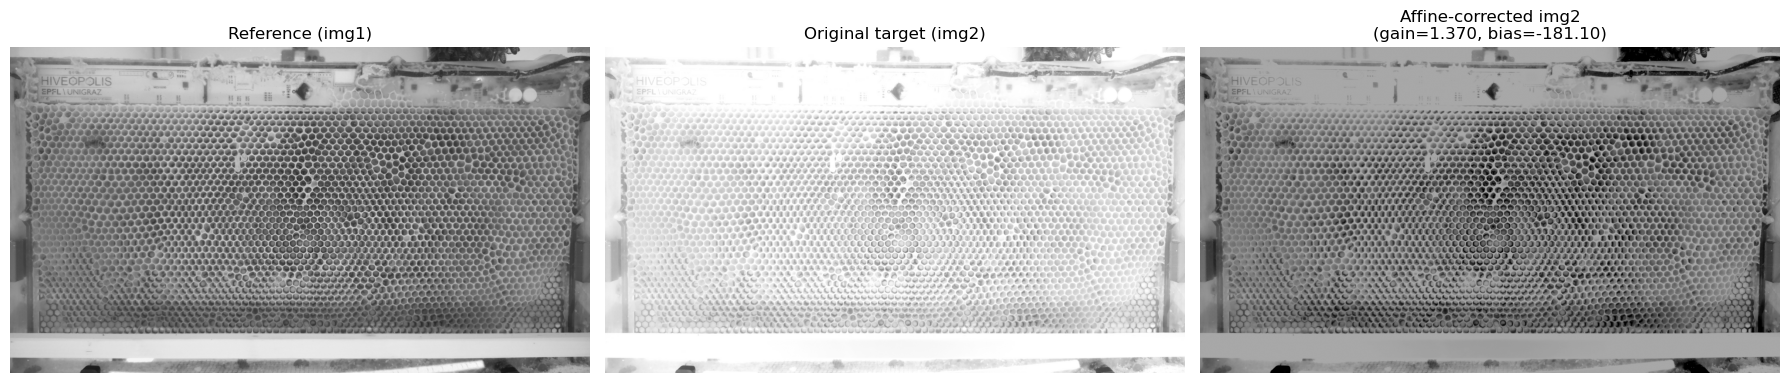

In [3]:
# Test the estimate_affine_exposure_correction function
img1 = "/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/h1r2_1minute/hive1_rpi2_250113-104501Z.jpg"
img2 = "/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/h1r2_1minute/hive1_rpi2_250113-104601Z.jpg"

img1_gray = cv2.imread(img1, cv2.IMREAD_GRAYSCALE)
img2_gray = cv2.imread(img2, cv2.IMREAD_GRAYSCALE)

gain, bias = estimate_affine_exposure_correction(img1_gray, img2_gray)
print(f"Estimated gain={gain:.3f}, bias={bias:.2f}")

# Apply the affine correction to img2 so it should match img1's exposure
img2_affine = np.clip(img2_gray.astype(np.float32) * gain + bias, 0, 255).astype(np.uint8)

# Store the three images (reference, original target, affine-corrected target) for later
# inspection, both as in-memory variables and as files saved to disk.
affine_test_images = {
    "reference": img1_gray,
    "original_target": img2_gray,
    "affine_corrected_target": img2_affine,
}

output_dir = "Outputs/affine_exposure_correction"
os.makedirs(output_dir, exist_ok=True)
for name, img in affine_test_images.items():
    out_path = os.path.join(output_dir, f"{name}.png")
    cv2.imwrite(out_path, img)
    print(f"Saved {name} to {out_path}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img1_gray, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Reference (img1)")
axes[0].axis("off")

axes[1].imshow(img2_gray, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Original target (img2)")
axes[1].axis("off")

axes[2].imshow(img2_affine, cmap="gray", vmin=0, vmax=255)
axes[2].set_title(f"Affine-corrected img2\n(gain={gain:.3f}, bias={bias:.2f})")
axes[2].axis("off")

plt.tight_layout()
plt.show()


In [3]:
# Open the jpg images in the folder and compute their mean pixel value, then plot a histogram of the mean pixel values
jpg_files = [f for f in os.listdir(path) if f.endswith(".jpg")]
sane_jpg_files = [f for f in os.listdir(sane_path) if f.endswith(".jpg")]

def compute_mean(filepath):
    # IMREAD_REDUCED_COLOR_4 decodes the JPEG at 1/4 resolution, which is much
    # faster than decoding full-size and then downsampling, and is plenty
    # accurate for a mean-pixel-value estimate.
    img = cv2.imread(filepath, cv2.IMREAD_REDUCED_COLOR_4)
    return img.mean()

with ThreadPoolExecutor() as executor:
    mean_pixel_values = list(tqdm(
        executor.map(compute_mean, (os.path.join(path, f) for f in jpg_files)),
        total=len(jpg_files),
    ))
    sane_mean_pixel_values = list(tqdm(
        executor.map(compute_mean, (os.path.join(sane_path, f) for f in sane_jpg_files)),
        total=len(sane_jpg_files),
    ))

plt.hist(mean_pixel_values, bins=50, alpha=0.6, label="path")
plt.hist(sane_mean_pixel_values, bins=50, color="orange", alpha=0.6, label="sane_path")
plt.xlabel("Mean pixel value")
plt.ylabel("Count")
plt.legend()
plt.show()

 24%|██▍       | 20277/83259 [01:00<03:07, 336.73it/s]


KeyboardInterrupt: 

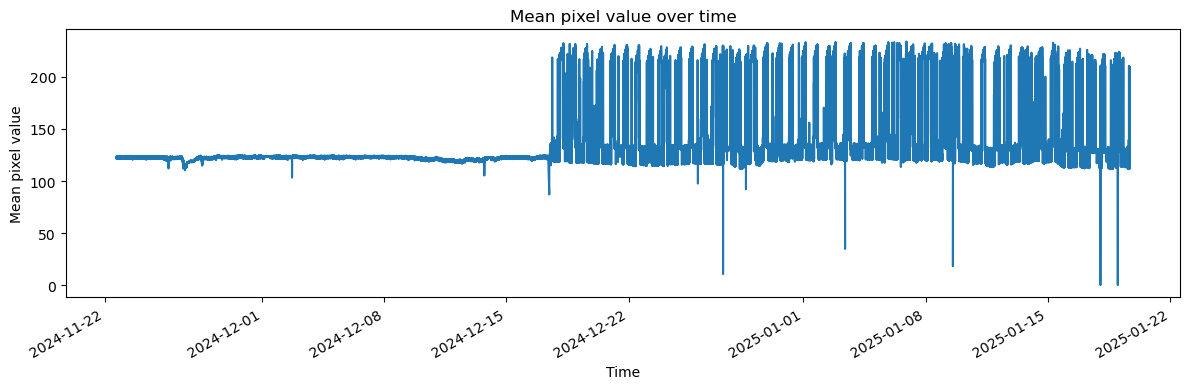

In [ ]:
def parse_timestamp(filename):
    # Filenames look like: hive1_rpi2_241122-161001Z.jpg -> 2024-11-22 16:10:01
    match = re.search(r"(\d{6}-\d{6})Z\.jpg$", filename)
    return datetime.datetime.strptime(match.group(1), "%y%m%d-%H%M%S")

timestamps = [parse_timestamp(f) for f in jpg_files]

# Sort by time, since directory listing order isn't guaranteed to be chronological
sorted_timestamps, sorted_mean_pixel_values, sorted_files = zip(*sorted(zip(timestamps, mean_pixel_values, jpg_files)))

plt.figure(figsize=(12, 4))
plt.plot(sorted_timestamps, sorted_mean_pixel_values)
plt.xlabel("Time")
plt.ylabel("Mean pixel value")
plt.title("Mean pixel value over time")
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Sane mean pixel value (before 2025-10-16): 141.1, from 83341 images
Target mean pixel value (+50%): 200.4
Found 267 candidate images within 10.0 of the target
Chosen image: hive1_rpi2_250117-085401Z.jpg (mean=199.4)


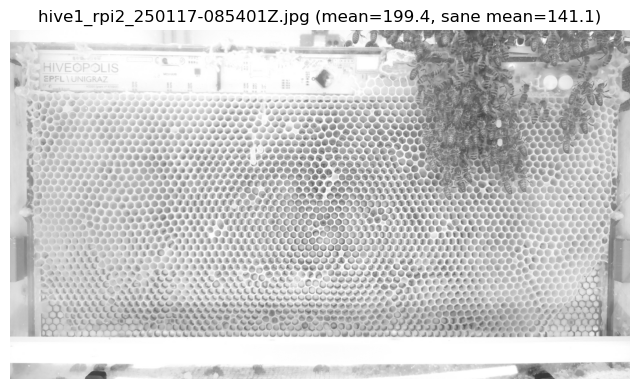

In [50]:
# Use pre-bug images (before the exposure issue started) as a "sane" baseline,
# then look for an image that's ~50% brighter but not fully saturated/unusable.
cutoff = datetime.datetime(2025, 10, 16)

sane_values = [v for t, v in zip(timestamps, mean_pixel_values) if t < cutoff]
sane_mean = statistics.mean(sane_values)
print(f"Sane mean pixel value (before {cutoff.date()}): {sane_mean:.1f}, from {len(sane_values)} images")

target = sane_mean * 1.42
print(f"Target mean pixel value (+50%): {target:.1f}")

# Candidates within 5% of the target, so we don't just grab a maxed-out/saturated image
tolerance = 0.05 * target
candidates = [i for i, v in enumerate(mean_pixel_values) if abs(v - target) <= tolerance]
print(f"Found {len(candidates)} candidate images within {tolerance:.1f} of the target")

chosen_idx = random.choice(candidates)
chosen_file = jpg_files[chosen_idx]
print(f"Chosen image: {chosen_file} (mean={mean_pixel_values[chosen_idx]:.1f})")

img_candidate = cv2.imread(os.path.join(path, chosen_file), cv2.IMREAD_GRAYSCALE)  # full resolution

plt.figure(figsize=(8, 6))
plt.imshow(img_candidate, cmap="gray", vmin=0, vmax=255)
plt.title(f"{chosen_file} (mean={mean_pixel_values[chosen_idx]:.1f}, sane mean={sane_mean:.1f})")
plt.axis("off")
plt.show()

Sane frame:   hive1_rpi2_241219-051401Z.jpg (mean=138.5) @ 2024-12-19 05:14:01
Bugged frame: hive1_rpi2_241219-051501Z.jpg (mean=198.6) @ 2024-12-19 05:15:01
Applied gain: 0.708
Applied gamma: 2.400
Pixels differing from the sane frame by more than 25:
  Raw (uncorrected)   : 11598618 / 11943936 pixels (97.1%)
  Linear gain         :  1559721 / 11943936 pixels (13.1%)
  Gamma correction    :  3304988 / 11943936 pixels (27.7%)
  CLAHE               :  7009765 / 11943936 pixels (58.7%)
  Histogram matched   :   428526 / 11943936 pixels (3.6%)


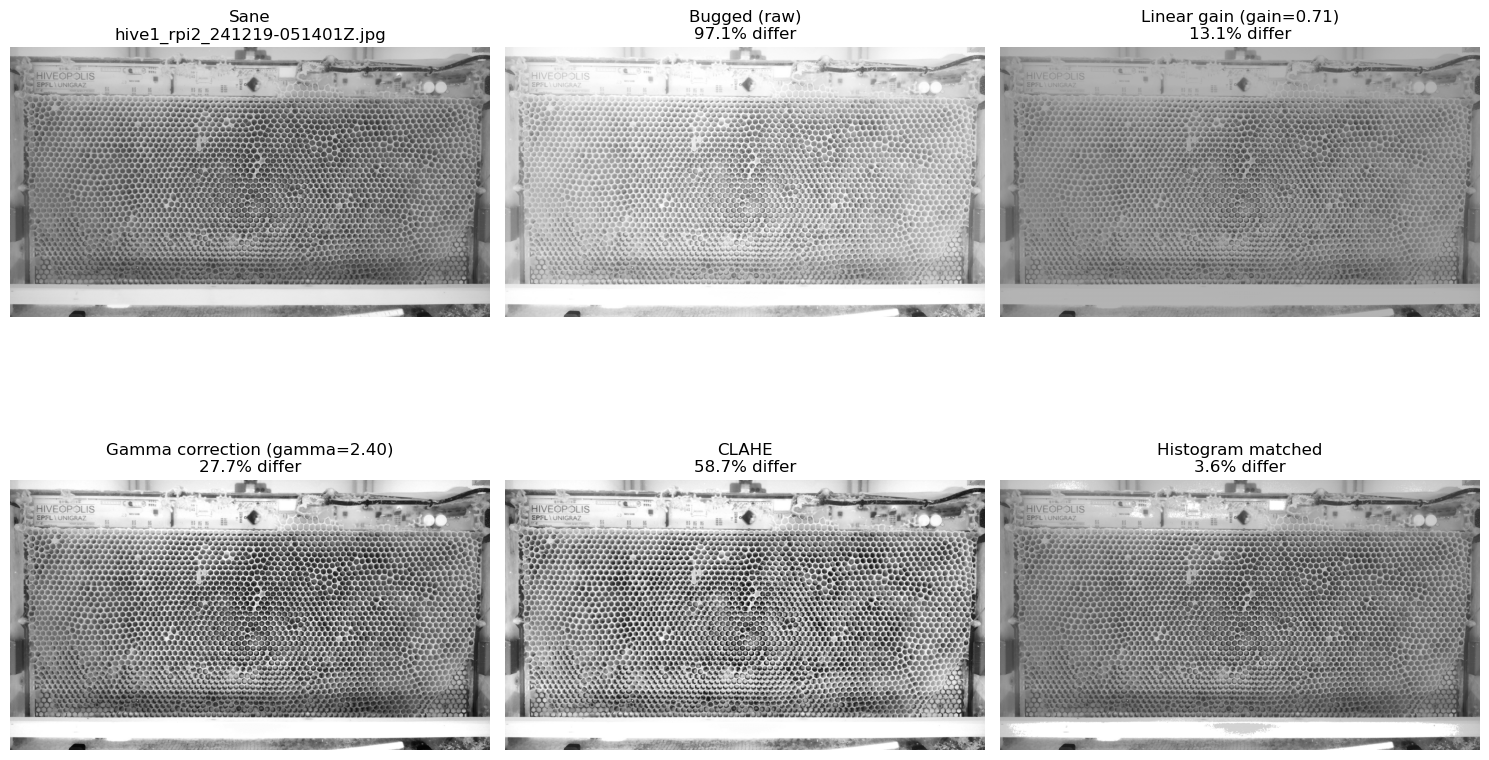

In [45]:
# Find two consecutive (in time) frames where one is close to the sane mean and the
# very next one is far from it - i.e. the exposure bug kicking in from one frame to the next.
close_tol = 0.1 * sane_mean       # "close" = within 10% of the sane mean
far_tol_min = 0.39 * sane_mean     # "far" = at least 40% away from the sane mean...
far_tol_max = 0.42 * sane_mean     # ...but not so far that it's fully saturated/unrecoverable

def is_close(v):
    return abs(v - sane_mean) <= close_tol

def is_far(v):
    return far_tol_min <= abs(v - sane_mean) <= far_tol_max

pair = None
for i in range(len(sorted_mean_pixel_values) - 1):
    v0, v1 = sorted_mean_pixel_values[i], sorted_mean_pixel_values[i + 1]
    if is_close(v0) and is_far(v1):
        pair = (i, i + 1)
        break
    if is_far(v0) and is_close(v1):
        pair = (i, i + 1)
        break

if pair is None:
    raise RuntimeError("No successive sane/bugged pair found - try loosening close_tol/far_tol_min/far_tol_max")

sane_idx, bugged_idx = pair
if sorted_mean_pixel_values[sane_idx] > sorted_mean_pixel_values[bugged_idx]:
    sane_idx, bugged_idx = bugged_idx, sane_idx

sane_file = sorted_files[sane_idx]
bugged_file = sorted_files[bugged_idx]
print(f"Sane frame:   {sane_file} (mean={sorted_mean_pixel_values[sane_idx]:.1f}) @ {sorted_timestamps[sane_idx]}")
print(f"Bugged frame: {bugged_file} (mean={sorted_mean_pixel_values[bugged_idx]:.1f}) @ {sorted_timestamps[bugged_idx]}")

img_sane = cv2.imread(os.path.join(path, sane_file), cv2.IMREAD_GRAYSCALE)
img_bugged = cv2.imread(os.path.join(path, bugged_file), cv2.IMREAD_GRAYSCALE)

# Try a few different ways of recovering the original exposure/detail from the bugged
# frame, since a plain linear correction may not be the best match for a nonlinear
# sensor/JPEG response, or may not reveal detail hidden in flat, near-white regions.

# Method 1: linear gain correction - scale so the mean matches the sane baseline.
gain = sane_mean / img_bugged.mean()
img_linear = np.clip(img_bugged.astype(np.float32) * gain, 0, 255).astype(np.uint8)
print(f"Applied gain: {gain:.3f}")

# Method 2: gamma correction - a power-law curve, which can better match a camera's
# nonlinear response than a simple linear scale, especially near the highlights.
gamma = np.log(sane_mean / 255) / np.log(img_bugged.mean() / 255)
img_gamma = np.clip(255 * (img_bugged / 255) ** gamma, 0, 255).astype(np.uint8)
print(f"Applied gamma: {gamma:.3f}")

# Method 3: CLAHE (contrast-limited adaptive histogram equalization) - locally boosts
# contrast without needing to estimate any gain, which can reveal detail flattened
# out by overexposure even where the average brightness is way off.
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_bugged)

# Method 4: histogram matching - directly reshapes the bugged image's intensity
# histogram to match the sane frame's histogram (skimage.exposure.match_histograms).
img_matched = match_histograms(img_bugged, img_sane).astype(np.uint8)

# Quantify how close each version is to the sane frame: count pixels whose absolute
# difference from the sane image exceeds a threshold, i.e. how many pixels are still
# "visibly wrong" after each correction.
diff_threshold = 25
methods = {
    "Raw (uncorrected)": img_bugged,
    "Linear gain": img_linear,
    "Gamma correction": img_gamma,
    "CLAHE": img_clahe,
    "Histogram matched": img_matched,
}

diff_pct = {}
print(f"Pixels differing from the sane frame by more than {diff_threshold}:")
for name, img in methods.items():
    diff = np.abs(img.astype(np.int16) - img_sane.astype(np.int16))
    count = int(np.count_nonzero(diff > diff_threshold))
    pct = 100 * count / diff.size
    diff_pct[name] = pct
    print(f"  {name:<20}: {count:>8} / {diff.size} pixels ({pct:.1f}%)")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes[0, 0].imshow(img_sane, cmap="gray", vmin=0, vmax=255)
axes[0, 0].set_title(f"Sane\n{sane_file}")
axes[0, 1].imshow(img_bugged, cmap="gray", vmin=0, vmax=255)
axes[0, 1].set_title(f"Bugged (raw)\n{diff_pct['Raw (uncorrected)']:.1f}% differ")
axes[0, 2].imshow(img_linear, cmap="gray", vmin=0, vmax=255)
axes[0, 2].set_title(f"Linear gain (gain={gain:.2f})\n{diff_pct['Linear gain']:.1f}% differ")
axes[1, 0].imshow(img_gamma, cmap="gray", vmin=0, vmax=255)
axes[1, 0].set_title(f"Gamma correction (gamma={gamma:.2f})\n{diff_pct['Gamma correction']:.1f}% differ")
axes[1, 1].imshow(img_clahe, cmap="gray", vmin=0, vmax=255)
axes[1, 1].set_title(f"CLAHE\n{diff_pct['CLAHE']:.1f}% differ")
axes[1, 2].imshow(img_matched, cmap="gray", vmin=0, vmax=255)
axes[1, 2].set_title(f"Histogram matched\n{diff_pct['Histogram matched']:.1f}% differ")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
plt.show()